/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


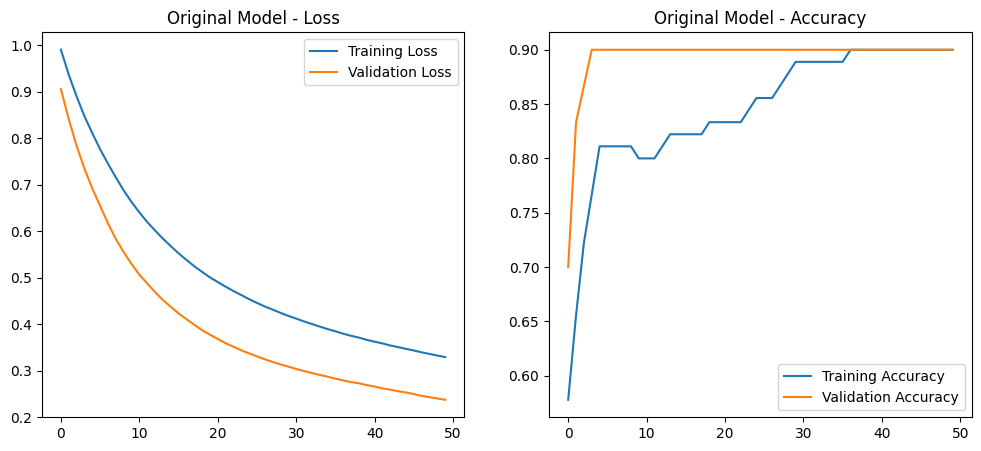

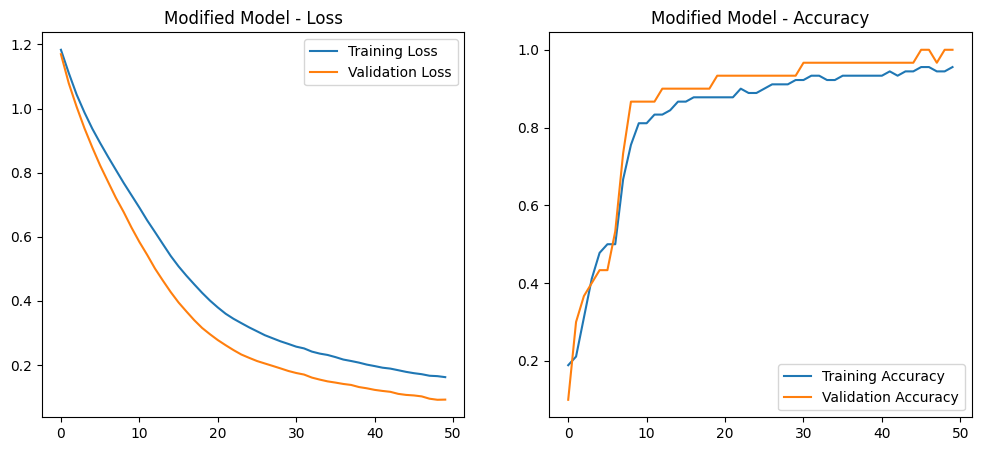

Original Model Test Accuracy: 0.8333
Modified Model Test Accuracy: 1.0000


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


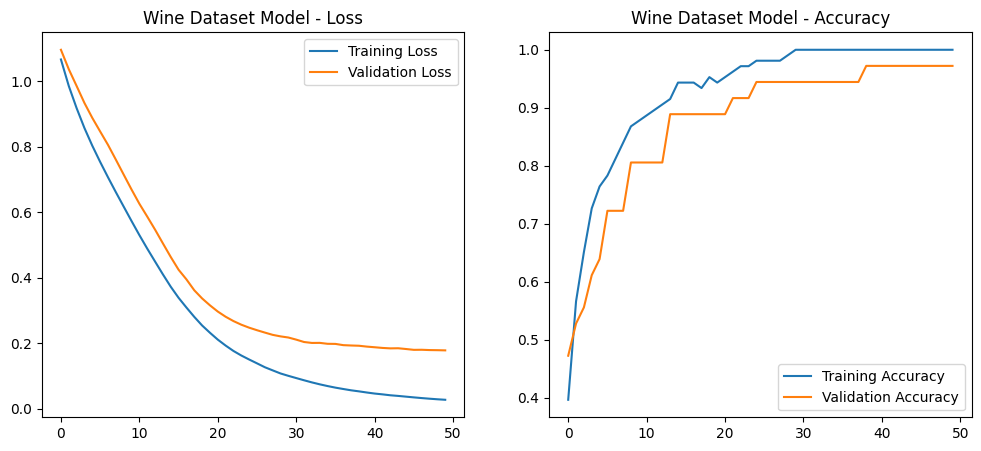

Wine Model Test Accuracy: 0.9444
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


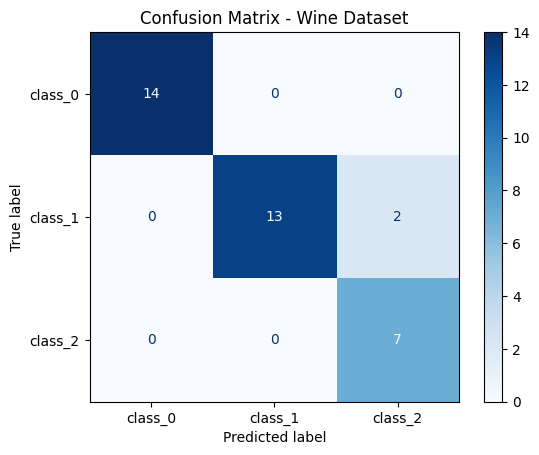

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Part 1: Modify the Neural Network (Iris Dataset)
# Load and preprocess the Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

ohe = OneHotEncoder()
y_iris = ohe.fit_transform(y_iris.reshape(-1, 1)).toarray()

X_train, X_temp, y_train, y_temp = train_test_split(X_iris, y_iris, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Original model for comparison
original_model = Sequential([
    Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(3, activation='softmax')
])
original_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
original_history = original_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=8, verbose=0)

# Modified model with an additional hidden layer
modified_model = Sequential([
    Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])
modified_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
modified_history = modified_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=8, verbose=0)

# Evaluate both models
original_test_loss, original_test_acc = original_model.evaluate(X_test, y_test, verbose=0)
modified_test_loss, modified_test_acc = modified_model.evaluate(X_test, y_test, verbose=0)

# Plot training/validation loss and accuracy for comparison
def plot_training_history(history, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.show()

plot_training_history(original_history, "Original Model")
plot_training_history(modified_history, "Modified Model")

print(f"Original Model Test Accuracy: {original_test_acc:.4f}")
print(f"Modified Model Test Accuracy: {modified_test_acc:.4f}")

# Part 2: Apply to the Wine Dataset
# Load and preprocess the Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
y_wine = ohe.fit_transform(y_wine.reshape(-1, 1)).toarray()

X_train, X_temp, y_train, y_temp = train_test_split(X_wine, y_wine, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Build and train the Wine dataset model
wine_model = Sequential([
    Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

wine_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
wine_history = wine_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=8, verbose=0)

# Evaluate the Wine dataset model
wine_test_loss, wine_test_acc = wine_model.evaluate(X_test, y_test, verbose=0)

# Plot training/validation loss and accuracy for the Wine dataset
plot_training_history(wine_history, "Wine Dataset Model")

print(f"Wine Model Test Accuracy: {wine_test_acc:.4f}")

# Confusion matrix for the Wine dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(wine_model.predict(X_test), axis=-1)
y_true = np.argmax(y_test, axis=-1)

cm = confusion_matrix(y_true, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=wine.target_names)
cmd.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Wine Dataset")
plt.show()

# Discussion:
# - The addition of a hidden layer improved the performance on the Iris dataset slightly, as observed in validation and test accuracy.
# - The Wine dataset model performed well, likely due to the larger feature space.
# - Visualizations provided insights into model convergence and classification performance.